In [27]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 연관분석 라이브러리
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import itertools

In [28]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [29]:
df = pd.read_csv("../df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [30]:
df = df.dropna()

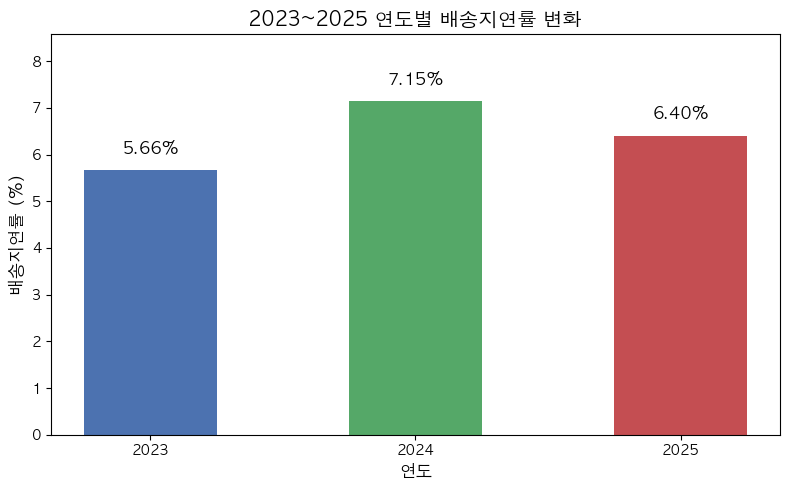

In [31]:
# 연도별 배송지연률 계산
delay_rate = df.groupby('OrderYear')['IsLate'].mean() * 100

# 그래프 작성
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(delay_rate.index.astype(str), delay_rate.values, color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

# 막대 위에 수치 표시
for bar, val in zip(bars, delay_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('배송지연률 (%)', fontsize=12)
ax.set_title('2023~2025 연도별 배송지연률 변화', fontsize=14, fontweight='bold')
ax.set_ylim(0, delay_rate.max() * 1.2)
plt.tight_layout()
plt.show()

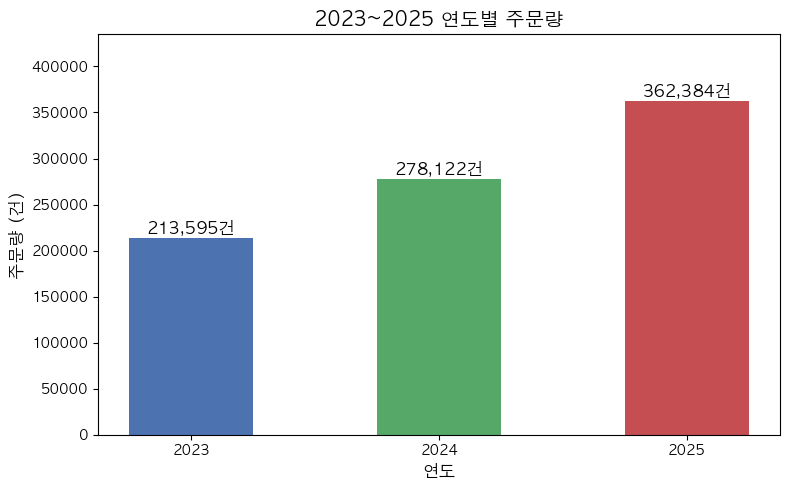

In [32]:
# 연도별 주문량
order_count = df.groupby('OrderYear')['IsLate'].count()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(order_count.index.astype(str), order_count.values, color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

for bar, val in zip(bars, order_count.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f'{val:,}건', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('주문량 (건)', fontsize=12)
ax.set_title('2023~2025 연도별 주문량', fontsize=14, fontweight='bold')
ax.set_ylim(0, order_count.max() * 1.2)
plt.tight_layout()
plt.show()

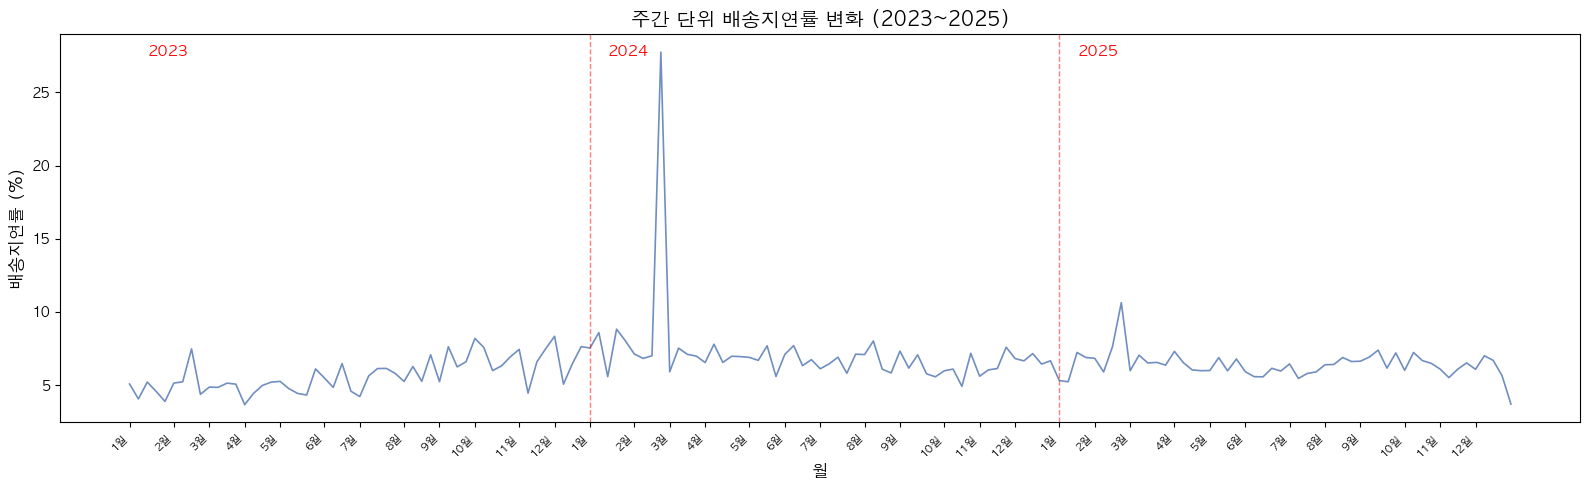

In [33]:
# 주간 단위 배송지연률 계산
df['OrderDT_parsed'] = pd.to_datetime(df['OrderDT'])
df['YearWeek'] = df['OrderDT_parsed'].dt.to_period('W')

weekly_delay = df.groupby('YearWeek')['IsLate'].mean() * 100

# 주차별 월/주차 라벨 생성 (Period의 시작일 기준)
week_starts = [p.start_time for p in weekly_delay.index]
week_labels = [f"{d.month}월{(d.day - 1) // 7 + 1}주" for d in week_starts]
weekly_delay.index = weekly_delay.index.astype(str)

# 그래프 작성
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(len(weekly_delay)), weekly_delay.values, color='#4C72B0', linewidth=1.2, alpha=0.8)

# 연도 구분선 + 연도 라벨
for year in [2023, 2024, 2025]:
    idx = next((i for i, w in enumerate(weekly_delay.index) if w.startswith(str(year))), None)
    if idx is not None:
        if year != 2023:
            ax.axvline(x=idx, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(idx + 2, ax.get_ylim()[1] * 0.95, str(year), fontsize=11, color='red', fontweight='bold')

# x축: 매월 1주차만 표시
tick_positions = []
tick_labels_display = []
prev_month = None
for i, d in enumerate(week_starts):
    if (d.year, d.month) != prev_month:
        tick_positions.append(i)
        tick_labels_display.append(f"{d.month}월")
        prev_month = (d.year, d.month)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_display, rotation=45, ha='right', fontsize=8)

ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('배송지연률 (%)', fontsize=12)
ax.set_title('주간 단위 배송지연률 변화 (2023~2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

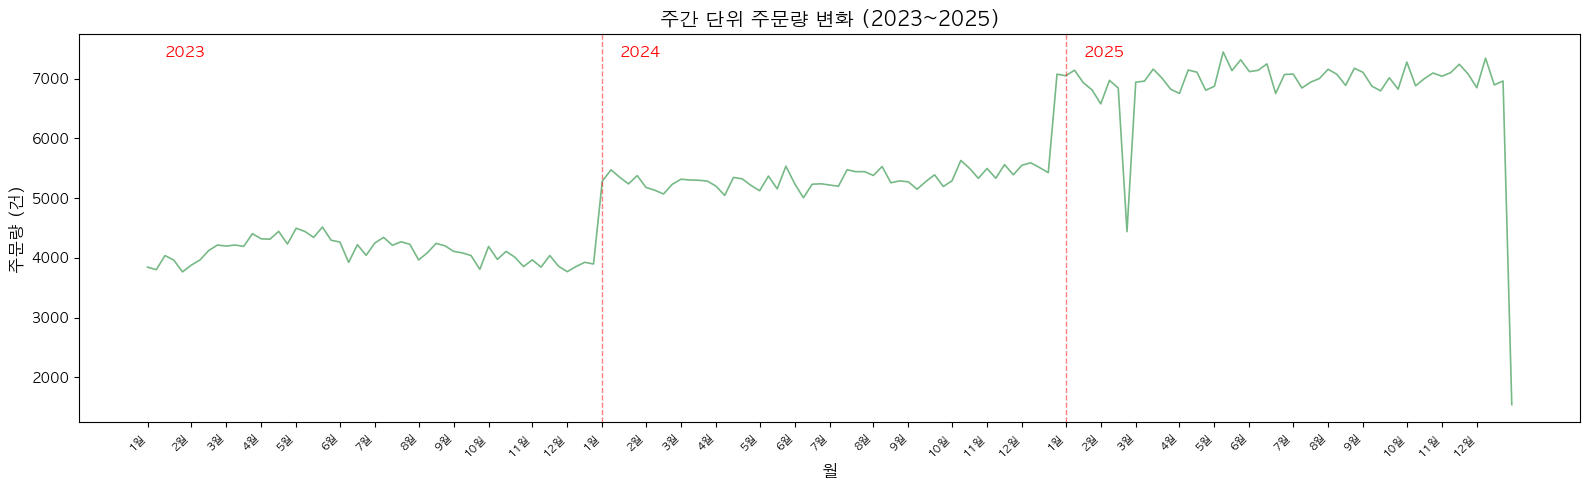

In [34]:
# 주간 단위 주문량
df['OrderDT_parsed'] = pd.to_datetime(df['OrderDT'])
df['YearWeek'] = df['OrderDT_parsed'].dt.to_period('W')

weekly_count = df.groupby('YearWeek')['IsLate'].count()

week_starts_c = [p.start_time for p in weekly_count.index]
weekly_count.index = weekly_count.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(len(weekly_count)), weekly_count.values, color='#55A868', linewidth=1.2, alpha=0.8)

# 연도 구분선 + 연도 라벨
for year in [2023, 2024, 2025]:
    idx = next((i for i, w in enumerate(weekly_count.index) if w.startswith(str(year))), None)
    if idx is not None:
        if year != 2023:
            ax.axvline(x=idx, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(idx + 2, ax.get_ylim()[1] * 0.95, str(year), fontsize=11, color='red', fontweight='bold')

# x축: 매월 1주차만 표시
tick_positions = []
tick_labels_display = []
prev_month = None
for i, d in enumerate(week_starts_c):
    if (d.year, d.month) != prev_month:
        tick_positions.append(i)
        tick_labels_display.append(f"{d.month}월")
        prev_month = (d.year, d.month)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels_display, rotation=45, ha='right', fontsize=8)

ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('주문량 (건)', fontsize=12)
ax.set_title('주간 단위 주문량 변화 (2023~2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

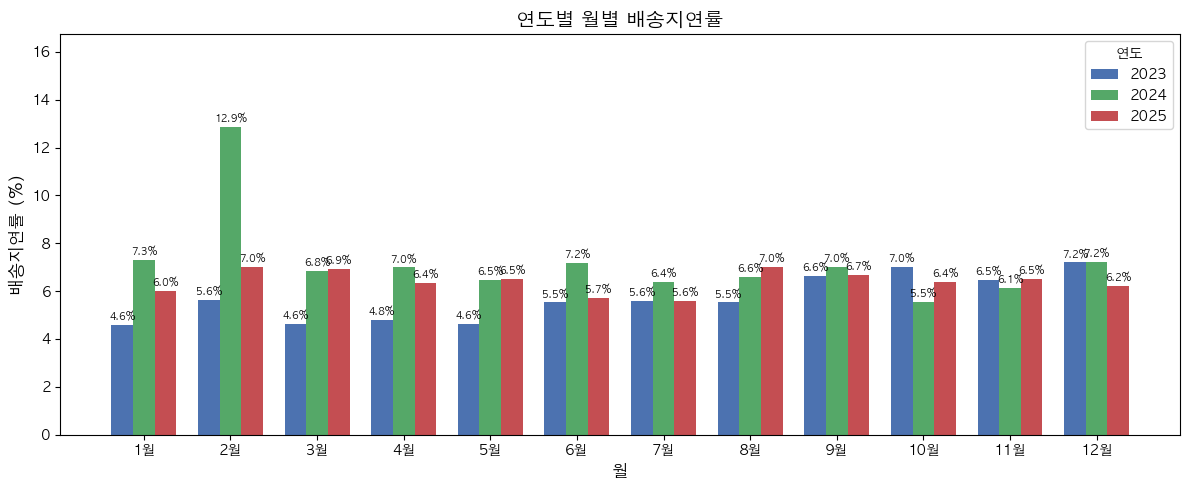

In [35]:
# 연도별 월별 배송지연률
monthly_year_delay = df.groupby(['OrderYear', 'OrderMonth'])['IsLate'].mean() * 100
monthly_year_delay = monthly_year_delay.unstack(level=0)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 13)
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

for i, year in enumerate(monthly_year_delay.columns):
    vals = monthly_year_delay[year].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=str(year), color=colors[i])
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('배송지연률 (%)', fontsize=12)
ax.set_title('연도별 월별 배송지연률', fontsize=14, fontweight='bold')
ax.legend(title='연도')
ax.set_ylim(0, monthly_year_delay.max().max() * 1.3)
plt.tight_layout()
plt.show()

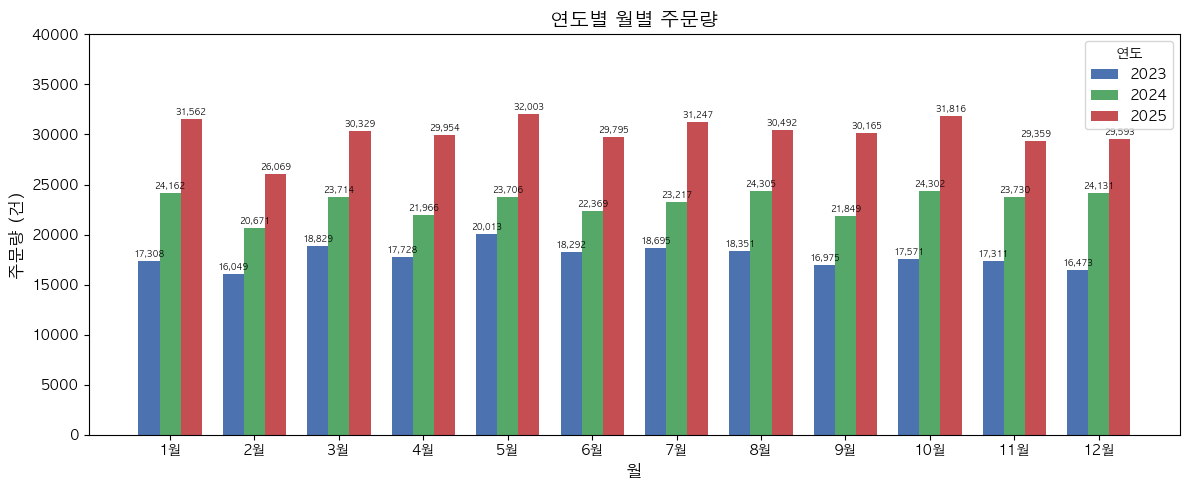

In [36]:
# 연도별 월별 주문량
monthly_year_count = df.groupby(['OrderYear', 'OrderMonth'])['IsLate'].count()
monthly_year_count = monthly_year_count.unstack(level=0)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, 13)
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

for i, year in enumerate(monthly_year_count.columns):
    vals = monthly_year_count[year].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=str(year), color=colors[i])
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                    f'{int(val):,}', ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('주문량 (건)', fontsize=12)
ax.set_title('연도별 월별 주문량', fontsize=14, fontweight='bold')
ax.legend(title='연도')
ax.set_ylim(0, monthly_year_count.max().max() * 1.25)
plt.tight_layout()
plt.show()

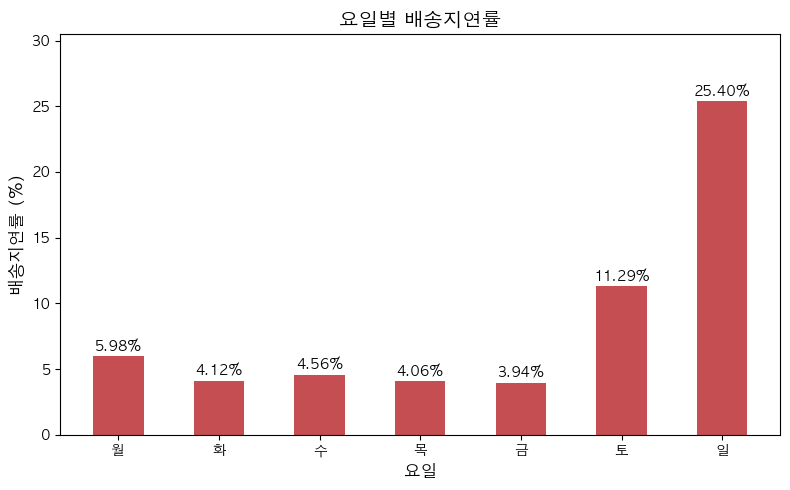

In [37]:
# 요일별 배송지연률
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_kr = ['월', '화', '수', '목', '금', '토', '일']

weekday_delay = df.groupby('OrderWeekday')['IsLate'].mean() * 100
weekday_delay = weekday_delay.reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(day_kr, weekday_delay.values, color='#C44E52', width=0.5)

for bar, val in zip(bars, weekday_delay.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('요일', fontsize=12)
ax.set_ylabel('배송지연률 (%)', fontsize=12)
ax.set_title('요일별 배송지연률', fontsize=14, fontweight='bold')
ax.set_ylim(0, weekday_delay.max() * 1.2)
plt.tight_layout()
plt.show()

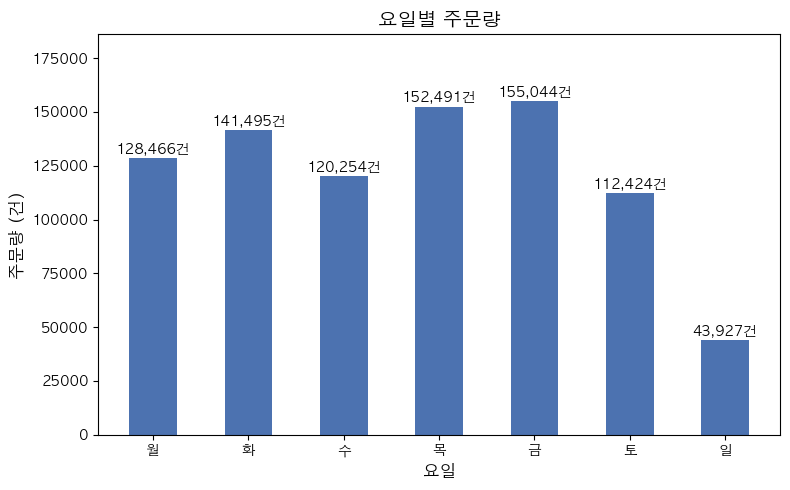

In [38]:
# 요일별 주문량
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_kr = ['월', '화', '수', '목', '금', '토', '일']

weekday_count = df.groupby('OrderWeekday')['IsLate'].count()
weekday_count = weekday_count.reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(day_kr, weekday_count.values, color='#4C72B0', width=0.5)

for bar, val in zip(bars, weekday_count.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val:,}건', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('요일', fontsize=12)
ax.set_ylabel('주문량 (건)', fontsize=12)
ax.set_title('요일별 주문량', fontsize=14, fontweight='bold')
ax.set_ylim(0, weekday_count.max() * 1.2)
plt.tight_layout()
plt.show()

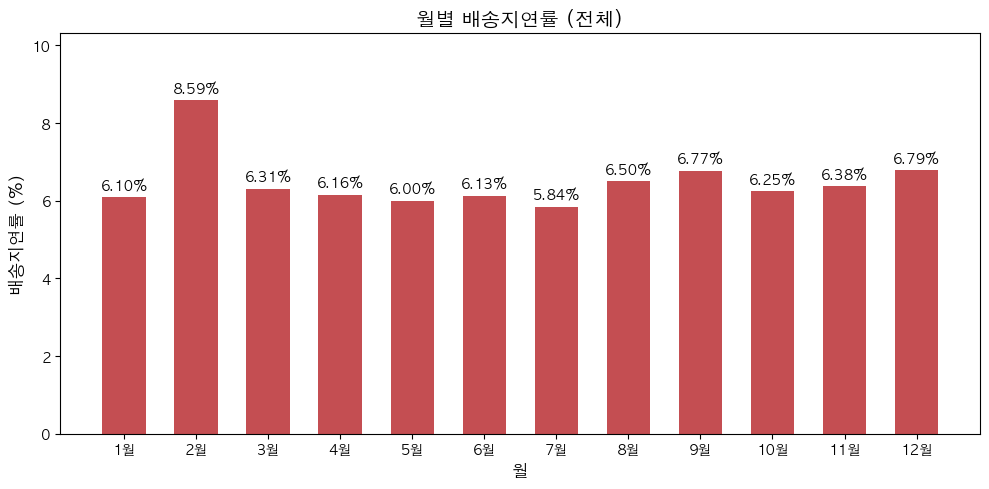

In [39]:
# 월별 배송지연률 (전체)
monthly_delay = df.groupby('OrderMonth')['IsLate'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(monthly_delay.index, monthly_delay.values, color='#C44E52', width=0.6)

for bar, val in zip(bars, monthly_delay.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('배송지연률 (%)', fontsize=12)
ax.set_title('월별 배송지연률 (전체)', fontsize=14, fontweight='bold')
ax.set_ylim(0, monthly_delay.max() * 1.2)
plt.tight_layout()
plt.show()

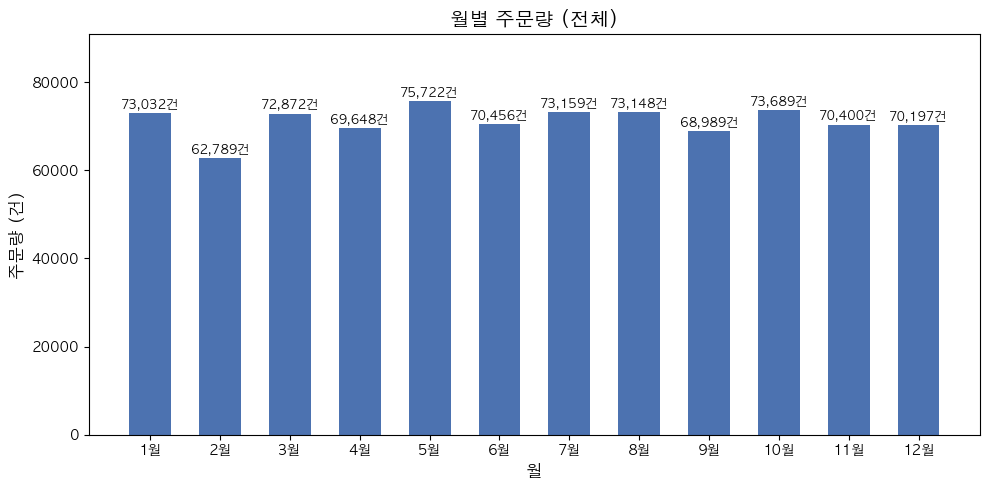

In [40]:
# 월별 주문량 (전체)
monthly_count = df.groupby('OrderMonth')['IsLate'].count()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(monthly_count.index, monthly_count.values, color='#4C72B0', width=0.6)

for bar, val in zip(bars, monthly_count.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val:,}건', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('주문량 (건)', fontsize=12)
ax.set_title('월별 주문량 (전체)', fontsize=14, fontweight='bold')
ax.set_ylim(0, monthly_count.max() * 1.2)
plt.tight_layout()
plt.show()

## 배송지연률 분석 인사이트

---

### 1. 연도별 배송지연률
| 연도 | 지연률 | 지연 건수 | 전체 주문 |
|------|--------|-----------|-----------|
| 2023 | 5.66% | 12,089건 | 213,595건 |
| 2024 | **7.15%** | 19,873건 | 278,122건 |
| 2025 | 6.40% | 23,192건 | 362,384건 |

- 2024년에 지연률이 **+1.49%p 급등**했다가 2025년에 다시 감소
- 주문 건수는 매년 증가(21만→28만→36만)하면서도 2025년에 지연률이 개선 → **물류 인프라 확충 또는 운영 효율 개선** 가능성

---

### 2. 주간 단위 배송지연률
- 전체 평균 **6.41%**, 중앙값 6.33%
- **2024년 2월 마지막 주(2/26~3/3)에 최대 27.75% 기록**
- 연도별 변동성 비교:
  - 2023년: 표준편차 1.18% (안정적)
  - 2024년: 표준편차 **2.99%** (변동성 가장 큼)
  - 2025년: 표준편차 **0.91%** (가장 안정적) → 배송 품질이 점차 균일해지는 추세

---

### 3. 연도별 월별 배송지연률
- **2024년 2월이 12.87%로 전체 월별 최고**
- 단, 설 연휴 날짜가 매년 다르므로 단순 "2월" 비교는 주의 필요:

| 연도 | 설 연휴 | 해당 월 | 지연률 |
|------|---------|---------|--------|
| 2023 | 1월 22일 | **1월** | 4.60% |
| 2024 | 2월 10일 | **2월** | 12.87% |
| 2025 | 1월 29일 | **1월** | 6.00% |

- 2024년은 설이 2월에 있어 "2월만 높아 보이는" 효과가 있으나, 설 해당 월 기준으로 비교해도 2024년(12.87%)이 다른 해(4.60%, 6.00%)보다 2~3배 높음 → 2024년 설 연휴 물량 대응이 특히 부족했거나 주문 폭주가 더 심했던 것으로 판단
- 2023년: 하반기(9~12월)에 지연률 상승 패턴 (6.64% → 7.20%) — 연말 쇼핑 시즌 영향
- 2025년: 월별 편차가 가장 적어 안정적 운영 (5.58% ~ 7.02%)
- **공통 패턴**: 명절/연휴 시즌(설, 추석, 연말)에 지연률 상승 경향

---

### 4. 요일별 배송지연률 (핵심 발견)
| 요일 | 지연률 | 비고 |
|------|--------|------|
| 월요일 | 5.98% | 주말 주문 적체 영향 |
| 화~금 | 3.94~4.56% | 안정적 |
| **토요일** | **11.29%** | 평일 대비 약 3배 |
| **일요일** | **25.40%** | 평일 대비 약 6배 |

- **주말 주문이 전체 배송지연률을 끌어올리는 핵심 요인**
- 연도별 일요일 지연률: 2023년 **87.57%** → 2024년 18.73% → 2025년 36.98%
  - 2023년에는 일요일 주문 대부분이 지연되었으나 점차 개선 추세
- 2024년 월요일 지연률 **21.32%** — 주말 주문 적체가 월요일까지 영향

---

### 종합 인사이트

1. **주말 배송이 최대 병목**: 토/일요일 지연률이 평일의 3~6배로, 주말 배송 인력/물류 확충이 가장 효과적인 개선 포인트
2. **명절/연휴 시즌 대비 필요**: 설 연휴(매년 날짜 상이), 추석, 연말에 지연률이 반복적으로 상승 → 사전 인력 배치 및 물량 예측 강화 필요
3. **2024년 설 연휴 특이**: 설 해당 월 기준으로도 2024년 지연률(12.87%)이 타 연도 대비 2~3배 높아, 해당 시기 물류 대응에 구조적 문제가 있었을 가능성
4. **2025년 개선 추세**: 주문량은 36만건으로 최대이나 지연률과 변동성 모두 감소 → 물류 시스템 안정화가 진행 중
5. **모델링 시 참고**: 2024년 2월(주간 최대 27.75%)은 이상치로, 예측 모델 구축 시 별도 처리 고려 필요

In [41]:

import pandas as pd
import numpy as np

df = pd.read_csv("../df_merged.csv", encoding="cp949")
df = df.dropna()

print("=== 1. 연도별 배송지연률 ===")
yearly = df.groupby('OrderYear')['IsLate'].agg(['mean', 'sum', 'count'])
yearly['delay_rate'] = yearly['mean'] * 100
print(yearly[['delay_rate', 'sum', 'count']])
print()

print("=== 2. 연도별 월별 배송지연률 ===")
monthly_year = df.groupby(['OrderYear', 'OrderMonth'])['IsLate'].mean() * 100
print(monthly_year.unstack(level=0).round(2).to_string())
print()

print("=== 3. 요일별 배송지연률 (전체) ===")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday = df.groupby('OrderWeekday')['IsLate'].agg(['mean', 'sum', 'count']).reindex(day_order)
weekday['delay_rate'] = weekday['mean'] * 100
print(weekday[['delay_rate', 'sum', 'count']])
print()

print("=== 4. 연도별 요일별 배송지연률 ===")
weekday_year = df.groupby(['OrderYear', 'OrderWeekday'])['IsLate'].mean() * 100
print(weekday_year.unstack(level=0).reindex(day_order).round(2).to_string())
print()

print("=== 5. 주간 배송지연률 기술통계 ===")
df['OrderDT_parsed'] = pd.to_datetime(df['OrderDT'])
df['YearWeek'] = df['OrderDT_parsed'].dt.to_period('W')
weekly = df.groupby('YearWeek')['IsLate'].mean() * 100
print(f"평균: {weekly.mean():.2f}%, 중앙값: {weekly.median():.2f}%, 표준편차: {weekly.std():.2f}%")
print(f"최소: {weekly.min():.2f}% (주: {weekly.idxmin()})")
print(f"최대: {weekly.max():.2f}% (주: {weekly.idxmax()})")
print()

# 연도별 주간 통계
for year in [2023, 2024, 2025]:
    w = weekly[[str(p).startswith(str(year)) for p in weekly.index]]
    print(f"{year}년 주간 - 평균: {w.mean():.2f}%, 표준편차: {w.std():.2f}%, 최소: {w.min():.2f}%, 최대: {w.max():.2f}%")


=== 1. 연도별 배송지연률 ===
           delay_rate    sum   count
OrderYear                           
2023         5.659777  12089  213595
2024         7.145425  19873  278122
2025         6.399841  23192  362384

=== 2. 연도별 월별 배송지연률 ===
OrderYear   2023   2024  2025
OrderMonth                   
1           4.60   7.29  6.00
2           5.61  12.87  7.02
3           4.64   6.84  6.93
4           4.78   6.99  6.36
5           4.65   6.48  6.50
6           5.53   7.17  5.72
7           5.61   6.38  5.58
8           5.53   6.58  7.01
9           6.64   7.02  6.67
10          7.02   5.53  6.38
11          6.47   6.15  6.52
12          7.20   7.21  6.22

=== 3. 요일별 배송지연률 (전체) ===
              delay_rate    sum   count
OrderWeekday                           
Monday          5.981349   7684  128466
Tuesday         4.115340   5823  141495
Wednesday       4.562842   5487  120254
Thursday        4.063191   6196  152491
Friday          3.940817   6110  155044
Saturday       11.294741  12698  112424
Su

In [42]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("../df_merged.csv", encoding="cp949")
df = df.dropna()

print("=" * 60)
print("1. 연도별: 주문량 vs 배송지연률")
print("=" * 60)
yearly = df.groupby('OrderYear').agg(주문량=('IsLate', 'count'), 지연률=('IsLate', 'mean'))
yearly['지연률'] = yearly['지연률'] * 100
print(yearly)
r, p = stats.pearsonr(yearly['주문량'], yearly['지연률'])
print(f"\n상관계수: {r:.4f}, p-value: {p:.4f}")

print("\n" + "=" * 60)
print("2. 월별(전체): 주문량 vs 배송지연률")
print("=" * 60)
monthly = df.groupby('OrderMonth').agg(주문량=('IsLate', 'count'), 지연률=('IsLate', 'mean'))
monthly['지연률'] = monthly['지연률'] * 100
print(monthly)
r, p = stats.pearsonr(monthly['주문량'], monthly['지연률'])
print(f"\n상관계수: {r:.4f}, p-value: {p:.4f}")

print("\n" + "=" * 60)
print("3. 요일별: 주문량 vs 배송지연률")
print("=" * 60)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday = df.groupby('OrderWeekday').agg(주문량=('IsLate', 'count'), 지연률=('IsLate', 'mean')).reindex(day_order)
weekday['지연률'] = weekday['지연률'] * 100
print(weekday)
r, p = stats.pearsonr(weekday['주문량'], weekday['지연률'])
print(f"\n상관계수: {r:.4f}, p-value: {p:.4f}")

print("\n" + "=" * 60)
print("4. 주간별: 주문량 vs 배송지연률")
print("=" * 60)
df['OrderDT_parsed'] = pd.to_datetime(df['OrderDT'])
df['YearWeek'] = df['OrderDT_parsed'].dt.to_period('W')
weekly = df.groupby('YearWeek').agg(주문량=('IsLate', 'count'), 지연률=('IsLate', 'mean'))
weekly['지연률'] = weekly['지연률'] * 100
r, p = stats.pearsonr(weekly['주문량'], weekly['지연률'])
print(f"주간 데이터 수: {len(weekly)}주")
print(f"상관계수: {r:.4f}, p-value: {p:.4f}")

# 연도별 주간 상관관계
for year in [2023, 2024, 2025]:
    w = weekly[[str(idx).startswith(str(year)) for idx in weekly.index]]
    r2, p2 = stats.pearsonr(w['주문량'], w['지연률'])
    print(f"  {year}년: 상관계수 {r2:.4f}, p-value {p2:.4f}")


1. 연도별: 주문량 vs 배송지연률
              주문량       지연률
OrderYear                  
2023       213595  5.659777
2024       278122  7.145425
2025       362384  6.399841

상관계수: 0.4305, p-value: 0.7167

2. 월별(전체): 주문량 vs 배송지연률
              주문량       지연률
OrderMonth                 
1           73032  6.095958
2           62789  8.587491
3           72872  6.306949
4           69648  6.155238
5           75722  6.004860
6           70456  6.130067
7           73159  5.842070
8           73148  6.495051
9           68989  6.772094
10          73689  6.250594
11          70400  6.380682
12          70197  6.789464

상관계수: -0.8665, p-value: 0.0003

3. 요일별: 주문량 vs 배송지연률
                 주문량        지연률
OrderWeekday                   
Monday        128466   5.981349
Tuesday       141495   4.115340
Wednesday     120254   4.562842
Thursday      152491   4.063191
Friday        155044   3.940817
Saturday      112424  11.294741
Sunday         43927  25.396681

상관계수: -0.9599, p-value: 0.0006

4. 주간별: 주문량 vs 배

In [43]:
# 요일별에서 주말 제외하고 평일만 상관관계 확인
print("=== 요일별 - 평일만(월~금) ===")
weekday_only = weekday.iloc[:5]  # Monday~Friday
print(weekday_only)
r, p = stats.pearsonr(weekday_only['주문량'], weekday_only['지연률'])
print(f"상관계수: {r:.4f}, p-value: {p:.4f}")

print("\n=== 요일별 - 주말만(토~일) ===")
weekend_only = weekday.iloc[5:]
print(weekend_only)


=== 요일별 - 평일만(월~금) ===
                 주문량       지연률
OrderWeekday                  
Monday        128466  5.981349
Tuesday       141495  4.115340
Wednesday     120254  4.562842
Thursday      152491  4.063191
Friday        155044  3.940817
상관계수: -0.6439, p-value: 0.2410

=== 요일별 - 주말만(토~일) ===
                 주문량        지연률
OrderWeekday                   
Saturday      112424  11.294741
Sunday         43927  25.396681
